In [1]:
import pandas as pd
import numpy as np

matches = pd.read_csv('../data/raw/results.csv', encoding='latin-1')
print("✅ Loaded!", matches.shape)
matches.head()

✅ Loaded! (964, 37)


,Key Id,Tournament Id,tournament Name,Match Id,Match Name,Stage Name,Group Name,Group Stage,Knockout Stage,Replayed,...,Away Team Score Margin,Extra Time,Penalty Shootout,Score Penalties,Home Team Score Penalties,Away Team Score Penalties,Result,Home Team Win,Away Team Win,Draw
0,1,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA World Cup,M-1930-04,Romania v Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA World Cup,M-1930-05,Argentina v France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [2]:
# Extract year from Tournament Id
matches['Year'] = matches['Tournament Id'].str.extract(r'(\d{4})').astype(int)

# Keep relevant columns (only ones that exist in your data)
cols = ['Year', 'tournament Name', 'Stage Name', 'Group Name',
        'Home Team Name', 'Away Team Name',
        'Home Team Score', 'Away Team Score',
        'Home Team Score Margin', 'Extra Time',
        'Penalty Shootout', 'Result',
        'Home Team Win', 'Away Team Win', 'Draw']

cols = [c for c in cols if c in matches.columns]
df = matches[cols].copy()

print("✅ Clean dataframe shape:", df.shape)
print("Columns kept:", cols)
df.head()

✅ Clean dataframe shape: (964, 15)
Columns kept: ['Year', 'tournament Name', 'Stage Name', 'Group Name', 'Home Team Name', 'Away Team Name', 'Home Team Score', 'Away Team Score', 'Home Team Score Margin', 'Extra Time', 'Penalty Shootout', 'Result', 'Home Team Win', 'Away Team Win', 'Draw']


,Year,tournament Name,Stage Name,Group Name,Home Team Name,Away Team Name,Home Team Score,Away Team Score,Home Team Score Margin,Extra Time,Penalty Shootout,Result,Home Team Win,Away Team Win,Draw
0,1930,1930 FIFA World Cup,group stage,Group 1,France,Mexico,4,1,3,0,0,home team win,1,0,0
1,1930,1930 FIFA World Cup,group stage,Group 4,United States,Belgium,3,0,3,0,0,home team win,1,0,0
2,1930,1930 FIFA World Cup,group stage,Group 2,Yugoslavia,Brazil,2,1,1,0,0,home team win,1,0,0
3,1930,1930 FIFA World Cup,group stage,Group 3,Romania,Peru,3,1,2,0,0,home team win,1,0,0
4,1930,1930 FIFA World Cup,group stage,Group 1,Argentina,France,1,0,1,0,0,home team win,1,0,0


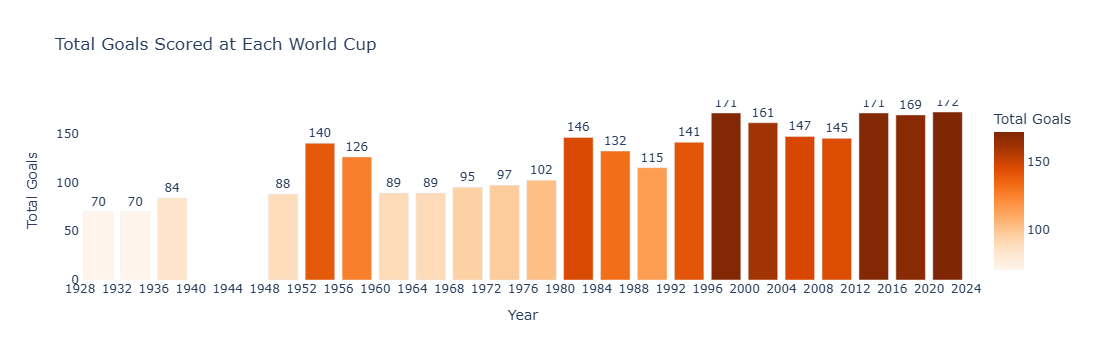

In [3]:
import plotly.express as px

goals_by_year = df.groupby('Year').apply(
    lambda x: x['Home Team Score'].sum() + x['Away Team Score'].sum()
).reset_index()
goals_by_year.columns = ['Year', 'Total Goals']

fig = px.bar(goals_by_year, x='Year', y='Total Goals',
             title='Total Goals Scored at Each World Cup',
             color='Total Goals', color_continuous_scale='Oranges',
             text='Total Goals')

fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, plot_bgcolor='white',
                  xaxis=dict(tickmode='linear', dtick=4))
fig.show()

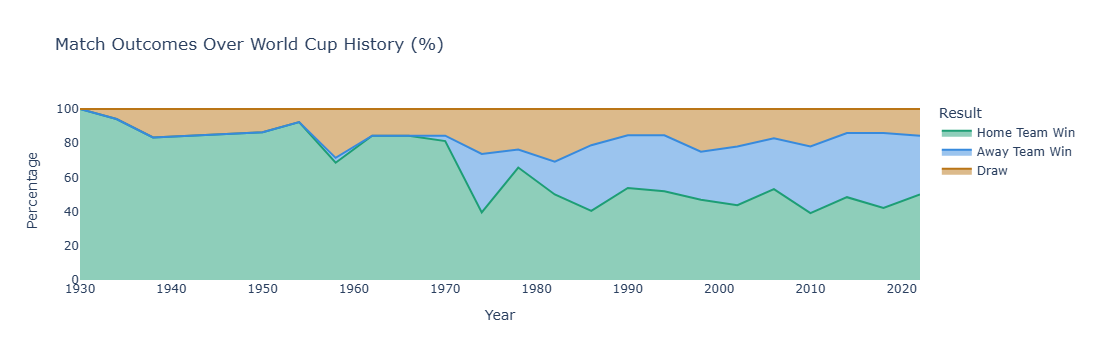

In [4]:
result_counts = df.groupby('Year')[['Home Team Win', 'Away Team Win', 'Draw']].sum()
result_counts = result_counts.div(result_counts.sum(axis=1), axis=0) * 100

fig = px.area(result_counts.reset_index(), x='Year',
              y=['Home Team Win', 'Away Team Win', 'Draw'],
              title='Match Outcomes Over World Cup History (%)',
              labels={'value': 'Percentage', 'variable': 'Result'},
              color_discrete_map={
                  'Home Team Win': '#1D9E75',
                  'Away Team Win': '#378ADD',
                  'Draw': '#BA7517'
              })

fig.update_layout(plot_bgcolor='white')
fig.show()

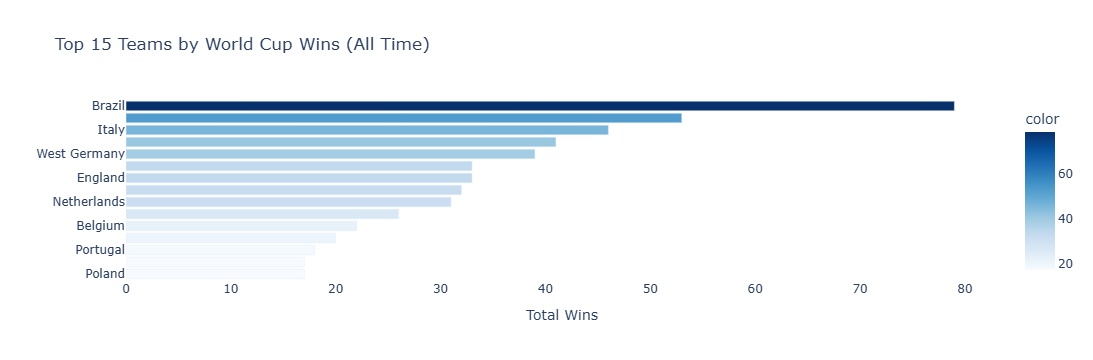

In [5]:
home_wins = df[df['Home Team Win'] == 1].groupby('Home Team Name').size()
away_wins = df[df['Away Team Win'] == 1].groupby('Away Team Name').size()

total_wins = (home_wins.add(away_wins, fill_value=0)
              .sort_values(ascending=True)
              .tail(15))

fig = px.bar(x=total_wins.values, y=total_wins.index,
             orientation='h',
             title='Top 15 Teams by World Cup Wins (All Time)',
             labels={'x': 'Total Wins', 'y': 'Team'},
             color=total_wins.values,
             color_continuous_scale='Blues')

fig.update_layout(showlegend=False, plot_bgcolor='white', yaxis_title='')
fig.show()

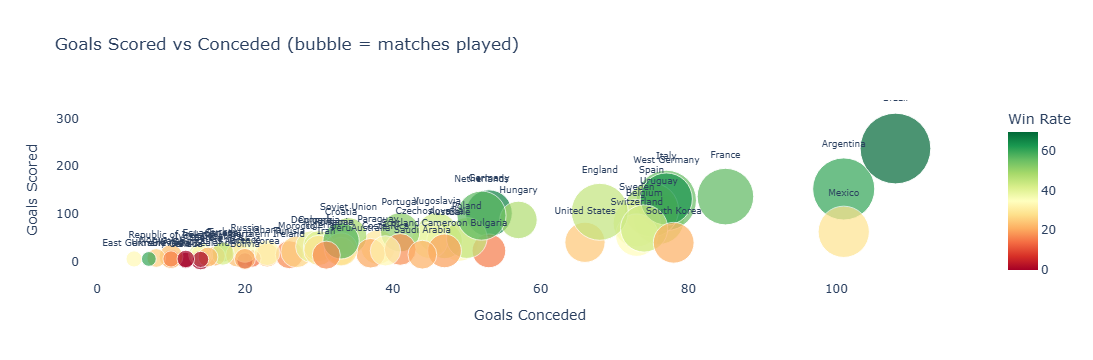

In [6]:
teams = df['Home Team Name'].unique()

stats = []
for team in teams:
    home = df[df['Home Team Name'] == team]
    away = df[df['Away Team Name'] == team]
    
    scored = home['Home Team Score'].sum() + away['Away Team Score'].sum()
    conceded = home['Away Team Score'].sum() + away['Home Team Score'].sum()
    games = len(home) + len(away)
    wins = home['Home Team Win'].sum() + away['Away Team Win'].sum()
    
    if games >= 5:
        stats.append({
            'Team': team, 'Games': games,
            'Goals Scored': scored, 'Goals Conceded': conceded,
            'Win Rate': round(wins / games * 100, 1)
        })

stats_df = pd.DataFrame(stats)

fig = px.scatter(stats_df, x='Goals Conceded', y='Goals Scored',
                 size='Games', color='Win Rate',
                 hover_name='Team', text='Team',
                 title='Goals Scored vs Conceded (bubble = matches played)',
                 color_continuous_scale='RdYlGn',
                 size_max=50)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(plot_bgcolor='white')
fig.show()

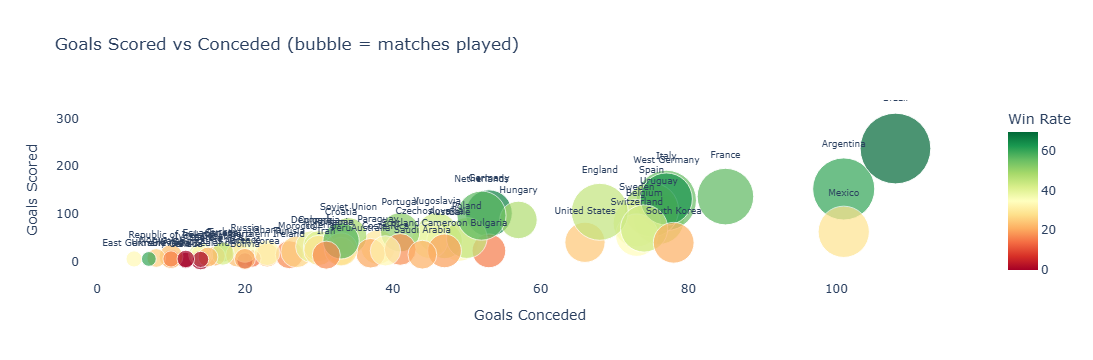

In [7]:
teams = df['Home Team Name'].unique()

stats = []
for team in teams:
    home = df[df['Home Team Name'] == team]
    away = df[df['Away Team Name'] == team]
    
    scored = home['Home Team Score'].sum() + away['Away Team Score'].sum()
    conceded = home['Away Team Score'].sum() + away['Home Team Score'].sum()
    games = len(home) + len(away)
    wins = home['Home Team Win'].sum() + away['Away Team Win'].sum()
    
    if games >= 5:
        stats.append({
            'Team': team, 'Games': games,
            'Goals Scored': scored, 'Goals Conceded': conceded,
            'Win Rate': round(wins / games * 100, 1)
        })

stats_df = pd.DataFrame(stats)

fig = px.scatter(stats_df, x='Goals Conceded', y='Goals Scored',
                 size='Games', color='Win Rate',
                 hover_name='Team', text='Team',
                 title='Goals Scored vs Conceded (bubble = matches played)',
                 color_continuous_scale='RdYlGn',
                 size_max=50)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(plot_bgcolor='white')
fig.show()

In [8]:
df.to_csv('../data/processed/matches_clean.csv', index=False)
stats_df.to_csv('../data/processed/team_stats.csv', index=False)

print("✅ Day 1 Complete!")
print(f"   matches_clean.csv — {df.shape[0]} matches saved")
print(f"   team_stats.csv — {stats_df.shape[0]} teams saved")

✅ Day 1 Complete!
   matches_clean.csv — 964 matches saved
   team_stats.csv — 64 teams saved
